In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
df = pd.read_csv('/content/campus_sustainability_dataset.csv')
df.head()

,Clothing_Spend_per_Month,Food_Type,Housing_Type,Energy_Usage_kWh_per_Month,Water_Usage_Liters_per_Day,Transportation_Mode,Consumption_Spend_per_Month,Recycling_Habits,Carbon_Emissions_kgCO2
0,1360,Non-Vegetarian,Apartment,478,277,Public_Transport,4136,Always,369.630
1,4272,Vegan,Own_House,69,151,Bicycle,4318,Always,158.860
2,3592,Vegetarian,Shared_House,322,124,Car,3782,Always,357.030
3,966,Non-Vegetarian,Shared_House,168,466,Public_Transport,8657,Never,247.745
4,4926,Vegetarian,Apartment,120,495,Walking,5920,Never,218.610


In [5]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clothing_Spend_per_Month     1000 non-null   int64  
 1   Food_Type                    1000 non-null   object 
 2   Housing_Type                 1000 non-null   object 
 3   Energy_Usage_kWh_per_Month   1000 non-null   int64  
 4   Water_Usage_Liters_per_Day   1000 non-null   int64  
 5   Transportation_Mode          1000 non-null   object 
 6   Consumption_Spend_per_Month  1000 non-null   int64  
 7   Recycling_Habits             1000 non-null   object 
 8   Carbon_Emissions_kgCO2       1000 non-null   float64
dtypes: float64(1), int64(4), object(4)
memory usage: 70.4+ KB


In [6]:
df.isnull().sum()

,0
Clothing_Spend_per_Month,0
Food_Type,0
Housing_Type,0
Energy_Usage_kWh_per_Month,0
Water_Usage_Liters_per_Day,0
Transportation_Mode,0
Consumption_Spend_per_Month,0
Recycling_Habits,0
Carbon_Emissions_kgCO2,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Clothing_Spend_per_Month,Energy_Usage_kWh_per_Month,Water_Usage_Liters_per_Day,Consumption_Spend_per_Month,Carbon_Emissions_kgCO2
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2815.422000,280.180000,268.24000,5450.880000,291.945620
std,1255.514921,132.122201,130.46957,2596.832641,80.767597
min,503.000000,50.000000,50.00000,1011.000000,102.995000
25%,1749.500000,165.750000,153.00000,3118.500000,227.812500
50%,2862.500000,277.000000,263.00000,5480.000000,291.940000
75%,3849.500000,399.000000,381.25000,7665.000000,346.975000
max,4999.000000,499.000000,499.00000,9989.000000,508.300000


In [9]:
print("Total Students:", len(df))
print("Average Carbon Emission:", df['Carbon_Emissions_kgCO2'].mean())
print("Average Energy Usage:", df['Energy_Usage_kWh_per_Month'].mean())
print("Average Water Usage:", df['Water_Usage_Liters_per_Day'].mean())

Total Students: 1000
Average Carbon Emission: 291.94562
Average Energy Usage: 280.18
Average Water Usage: 268.24


In [10]:
transport_carbon = df.groupby('Transportation_Mode')['Carbon_Emissions_kgCO2'].mean().sort_values(ascending=False)
print(transport_carbon)

Transportation_Mode
Car                 360.576813
Public_Transport    283.372306
Walking             263.571297
Bicycle             259.274782
Name: Carbon_Emissions_kgCO2, dtype: float64


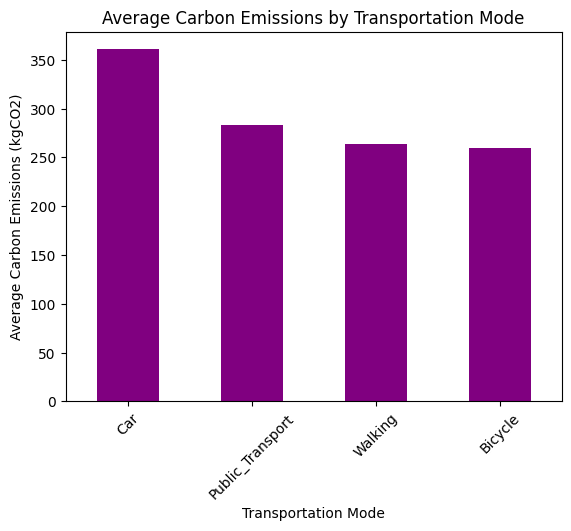

In [12]:
transport_carbon.plot(kind='bar', color='purple')
plt.title('Average Carbon Emissions by Transportation Mode')
plt.xlabel('Transportation Mode')
plt.ylabel('Average Carbon Emissions (kgCO2)')
plt.xticks(rotation=45)
plt.show()

Food_Type
Non-Vegetarian    307.787237
Mixed             293.507342
Vegetarian        289.847274
Vegan             275.765354
Name: Carbon_Emissions_kgCO2, dtype: float64


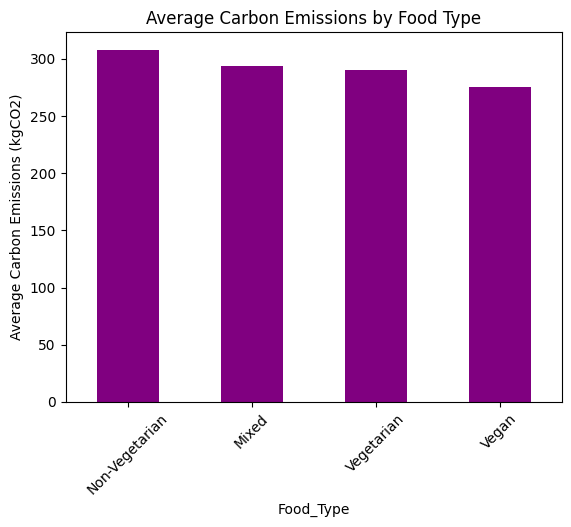

In [14]:
food_carbon = df.groupby('Food_Type')['Carbon_Emissions_kgCO2'].mean().sort_values(ascending=False)
print(food_carbon)

food_carbon.plot(kind='bar', color='purple')
plt.title('Average Carbon Emissions by Food Type')
plt.ylabel('Average Carbon Emissions (kgCO2)')
plt.xticks(rotation=45)
plt.show()

In [15]:
housing_data = df.groupby('Housing_Type')[['Energy_Usage_kWh_per_Month',
                                           'Water_Usage_Liters_per_Day']].mean()
print(housing_data)

              Energy_Usage_kWh_per_Month  Water_Usage_Liters_per_Day
Housing_Type                                                        
Apartment                     284.049430                  269.250951
Dormitory                     287.486275                  270.701961
Own_House                     281.804688                  274.046875
Shared_House                  265.592920                  257.707965


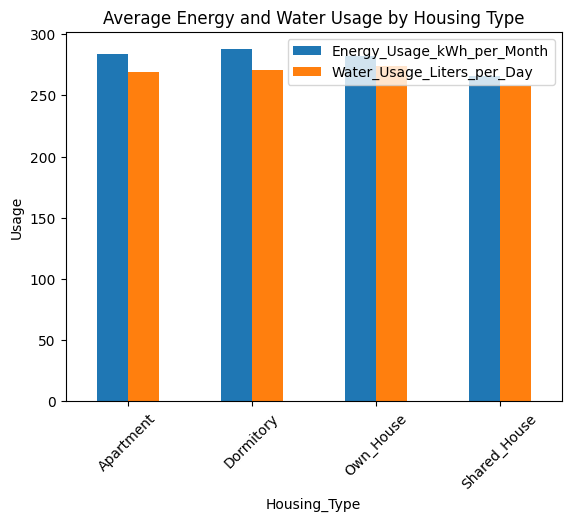

In [16]:
housing_data.plot(kind='bar')
plt.title('Average Energy and Water Usage by Housing Type')
plt.ylabel('Usage')
plt.xticks(rotation=45)
plt.show()

Recycling_Habits
Never        298.484675
Always       291.056517
Sometimes    287.160223
Name: Carbon_Emissions_kgCO2, dtype: float64


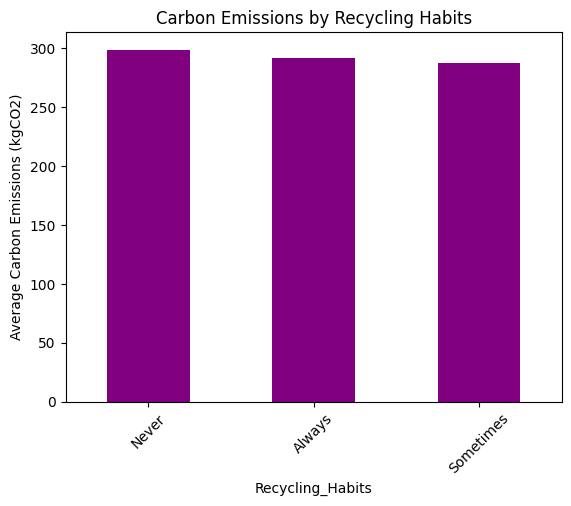

In [17]:
recycling_carbon = df.groupby('Recycling_Habits')['Carbon_Emissions_kgCO2'].mean().sort_values(ascending=False)
print(recycling_carbon)

recycling_carbon.plot(kind='bar', color='purple')
plt.title('Carbon Emissions by Recycling Habits')
plt.ylabel('Average Carbon Emissions (kgCO2)')
plt.xticks(rotation=45)
plt.show()

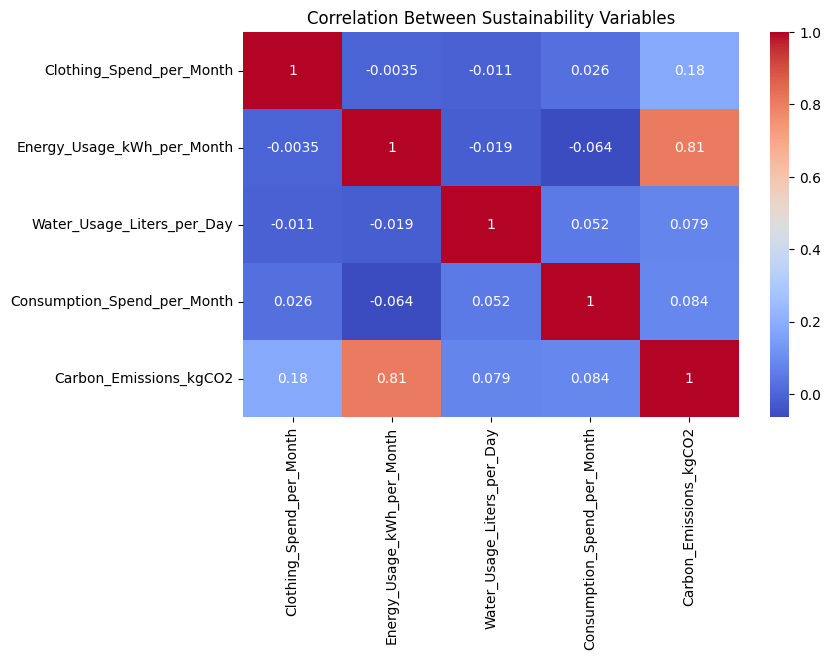

In [18]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Sustainability Variables')
plt.show()

In [27]:
from google.colab import files

df.to_csv('cleaned_campus_sustainability_dataset.csv', index=False)

files.download('cleaned_campus_sustainability_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>